This notebook evaluates a simple static baseline using logistic regression on mean-pooled clip-level pose features. It is intended as a comparison model against the primary temporal GRU.

In [56]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataset import load_processed_metadata
from src.train_baselines import (
    build_static_feature_matrix,
    run_logistic_regression_cv,
    BASELINE_RESULTS_PATH,
    BASELINE_PREDICTIONS_PATH,
    BASELINE_SUMMARY_PATH,
    BASELINE_CONFUSION_MATRIX_PATH,
)
from src.config import INDEX_TO_LABEL
from src.inference import predict_landing_quality_from_video

In [37]:
video_path = PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"

print(video_path)
print(video_path.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV
True


In [38]:
result = predict_landing_quality_from_video(video_path)

print(result.keys())
print("Number of overlay frames:", len(result["pose_overlay_frames"]))

if len(result["pose_overlay_frames"]) > 0:
    print("Overlay frame shape:", result["pose_overlay_frames"][0].shape)

I0000 00:00:1776131008.635425 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131008.741039 41633178 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131008.756944 41633178 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776131009.633079 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131009.735990 41633195 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131009.748544 41633195 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


dict_keys(['video_path', 'predicted_label', 'predicted_index', 'confidence', 'probabilities', 'num_sampled_frames', 'missing_pose_frames', 'processed_sequence_shape', 'pose_overlay_frames'])
Number of overlay frames: 4
Overlay frame shape: (1080, 1920, 3)


In [39]:
processed_meta = load_processed_metadata()

print("Number of processed clips:", len(processed_meta))
print(processed_meta["label"].value_counts())
processed_meta.head()

Number of processed clips: 30
label
bad_jump     15
good_jump    15
Name: count, dtype: int64


,clip_id,video_path,label,sequence_path,num_sampled_frames,missing_pose_frames,processed_shape
0,bad_jump_01,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,30,0,"(30, 132)"
1,bad_jump_02,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,30,0,"(30, 132)"
2,bad_jump_03,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,30,0,"(30, 132)"
3,bad_jump_04,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,30,1,"(30, 132)"
4,bad_jump_05,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,30,0,"(30, 132)"


In [40]:
X, y, clip_ids = build_static_feature_matrix(processed_meta)

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)
print("First clip ID:", clip_ids[0])

Feature matrix shape: (30, 132)
Label shape: (30,)
First clip ID: bad_jump_01


In [41]:
baseline_outputs = run_logistic_regression_cv(
    metadata_df=processed_meta,
    n_splits=5,
    save_results=True,
)

In [42]:
baseline_outputs["fold_results"]

,fold,accuracy,precision,recall,f1
0,1,0.666667,1.000000,0.333333,0.500000
1,2,0.666667,0.600000,1.000000,0.750000
2,3,0.666667,0.666667,0.666667,0.666667
3,4,0.500000,0.500000,0.333333,0.400000
4,5,0.666667,0.600000,1.000000,0.750000


In [43]:
baseline_outputs["summary"]

,metric,mean,std
0,accuracy,0.633333,0.074536
1,precision,0.673333,0.192065
2,recall,0.666667,0.333333
3,f1,0.613333,0.156968


In [44]:
baseline_outputs["confusion_matrix"]

,pred_0,pred_1
true_0,9,6
true_1,5,10


In [45]:
pred_df = baseline_outputs["predictions"].copy()
pred_df["true_label_name"] = pred_df["true_label"].map(INDEX_TO_LABEL)
pred_df["pred_label_name"] = pred_df["pred_label"].map(INDEX_TO_LABEL)

pred_df.head(10)

,fold,clip_id,true_label,pred_label,correct,true_label_name,pred_label_name
0,1,bad_jump_03,0,0,1,bad_jump,bad_jump
1,1,bad_jump_07,0,0,1,bad_jump,bad_jump
2,1,bad_jump_08,0,0,1,bad_jump,bad_jump
3,1,good_jump_03,1,0,0,good_jump,bad_jump
4,1,good_jump_10,1,1,1,good_jump,good_jump
5,1,good_jump_13,1,0,0,good_jump,bad_jump
6,2,bad_jump_05,0,1,0,bad_jump,good_jump
7,2,bad_jump_10,0,0,1,bad_jump,bad_jump
8,2,bad_jump_14,0,1,0,bad_jump,good_jump
9,2,good_jump_08,1,1,1,good_jump,good_jump


In [46]:
pred_df[pred_df["correct"] == 0]

,fold,clip_id,true_label,pred_label,correct,true_label_name,pred_label_name
3,1,good_jump_03,1,0,0,good_jump,bad_jump
5,1,good_jump_13,1,0,0,good_jump,bad_jump
6,2,bad_jump_05,0,1,0,bad_jump,good_jump
8,2,bad_jump_14,0,1,0,bad_jump,good_jump
13,3,bad_jump_11,0,1,0,bad_jump,good_jump
15,3,good_jump_04,1,0,0,good_jump,bad_jump
18,4,bad_jump_01,0,1,0,bad_jump,good_jump
21,4,good_jump_01,1,0,0,good_jump,bad_jump
22,4,good_jump_05,1,0,0,good_jump,bad_jump
24,5,bad_jump_04,0,1,0,bad_jump,good_jump


In [47]:
print(BASELINE_RESULTS_PATH, BASELINE_RESULTS_PATH.exists())
print(BASELINE_PREDICTIONS_PATH, BASELINE_PREDICTIONS_PATH.exists())
print(BASELINE_SUMMARY_PATH, BASELINE_SUMMARY_PATH.exists())
print(BASELINE_CONFUSION_MATRIX_PATH, BASELINE_CONFUSION_MATRIX_PATH.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_cv_results.csv True
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_cv_predictions.csv True
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_cv_summary.csv True
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_cv_confusion_matrix.npy True


Preliminary comparison: under the current settings, logistic regression on aggregated features outperforms the GRU sequence model. This suggests that the present temporal model may require further tuning or more data to realize an advantage.

In [48]:
from src.train_baselines import train_final_logistic_regression_model, BASELINE_MODEL_PATH

final_logreg_model = train_final_logistic_regression_model(processed_meta, save_model=True)

print(BASELINE_MODEL_PATH)
print(BASELINE_MODEL_PATH.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_model.joblib
True


In [49]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.inference import predict_landing_quality_from_video
from src.train_baselines import BASELINE_MODEL_PATH

print(BASELINE_MODEL_PATH)
print(BASELINE_MODEL_PATH.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/processed/logreg_model.joblib
True


In [50]:
sample_video = PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"
print(sample_video)
print(sample_video.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV
True


In [55]:
result = predict_landing_quality_from_video(sample_video)

print(result["predicted_label"])
print(result["confidence"])
print(result["processed_sequence_shape"])
print("Number of overlay frames:", len(result["pose_overlay_frames"]))

I0000 00:00:1776131722.388184 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131722.494106 41641083 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131722.506792 41641083 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776131723.426667 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131723.523051 41641099 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131723.535923 41641097 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


bad_jump
0.8572570072779883
(30, 132)
Number of overlay frames: 4


/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV
True


I0000 00:00:1776131070.006650 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131070.142489 41634142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131070.157218 41634142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776131071.134454 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776131071.234225 41634167 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776131071.247217 41634167 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


dict_keys(['video_path', 'predicted_label', 'predicted_index', 'confidence', 'probabilities', 'num_sampled_frames', 'missing_pose_frames', 'processed_sequence_shape', 'pose_overlay_frames'])
Predicted label: bad_jump
Confidence: 0.8572570072779883
Number of overlay frames: 4
Overlay frame shape: (1080, 1920, 3)


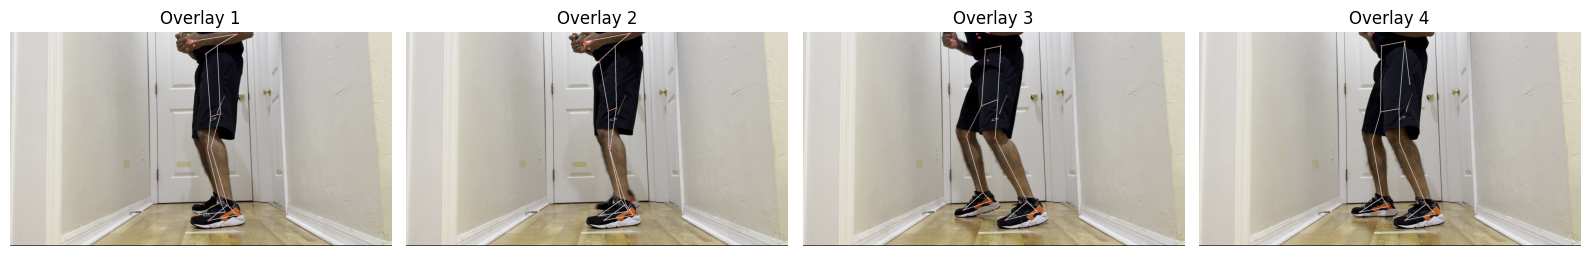

In [53]:
from src.inference import predict_landing_quality_from_video
import matplotlib.pyplot as plt

video_path = PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"

print(video_path)
print(video_path.exists())

result = predict_landing_quality_from_video(video_path)

print(result.keys())
print("Predicted label:", result["predicted_label"])
print("Confidence:", result["confidence"])
print("Number of overlay frames:", len(result["pose_overlay_frames"]))

if len(result["pose_overlay_frames"]) > 0:
    print("Overlay frame shape:", result["pose_overlay_frames"][0].shape)

overlay_frames = result["pose_overlay_frames"]

fig, axes = plt.subplots(1, len(overlay_frames), figsize=(16, 4))
if len(overlay_frames) == 1:
    axes = [axes]

for i, frame in enumerate(overlay_frames):
    axes[i].imshow(frame)
    axes[i].set_title(f"Overlay {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [57]:
bad_video = PROJECT_ROOT / "data" / "sample_videos" / "bad_jump_01.MOV"
good_video = PROJECT_ROOT / "data" / "sample_videos" / "good_jump_01.mov"

print("Bad exists:", bad_video.exists(), bad_video)
print("Good exists:", good_video.exists(), good_video)

Bad exists: True /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/sample_videos/bad_jump_01.MOV
Good exists: True /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/sample_videos/good_jump_01.mov


In [58]:
bad_result = predict_landing_quality_from_video(bad_video)

print("Bad clip prediction:")
print("Predicted label:", bad_result["predicted_label"])
print("Confidence:", bad_result["confidence"])
print("Number of overlay frames:", len(bad_result["pose_overlay_frames"]))
print("Processed sequence shape:", bad_result["processed_sequence_shape"])

I0000 00:00:1776132210.693139 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776132210.792868 41647917 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776132210.807407 41647917 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776132211.711270 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776132211.814012 41647931 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776132211.826862 41647931 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Bad clip prediction:
Predicted label: bad_jump
Confidence: 0.8572570072779883
Number of overlay frames: 4
Processed sequence shape: (30, 132)


In [59]:
good_result = predict_landing_quality_from_video(good_video)

print("Good clip prediction:")
print("Predicted label:", good_result["predicted_label"])
print("Confidence:", good_result["confidence"])
print("Number of overlay frames:", len(good_result["pose_overlay_frames"]))
print("Processed sequence shape:", good_result["processed_sequence_shape"])

I0000 00:00:1776132225.095778 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776132225.214916 41648151 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776132225.232023 41648151 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776132226.199106 41575711 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776132226.293308 41648172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776132226.305491 41648172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Good clip prediction:
Predicted label: good_jump
Confidence: 0.973777715392055
Number of overlay frames: 4
Processed sequence shape: (30, 132)


In [60]:
assert "pose_overlay_frames" in bad_result
assert "pose_overlay_frames" in good_result

assert len(bad_result["pose_overlay_frames"]) > 0
assert len(good_result["pose_overlay_frames"]) > 0

print("Overlay frames successfully returned for both clips.")

Overlay frames successfully returned for both clips.


In [62]:
def show_overlay_frames(result, title, max_frames=4):
    overlay_frames = result["pose_overlay_frames"][:max_frames]
    
    if len(overlay_frames) == 0:
        print(f"No overlay frames available for {title}")
        return
    
    plt.figure(figsize=(4 * len(overlay_frames), 4))
    
    for i, frame in enumerate(overlay_frames, 1):
        plt.subplot(1, len(overlay_frames), i)
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"{title}\nFrame {i}")
    
    plt.tight_layout()
    plt.show()

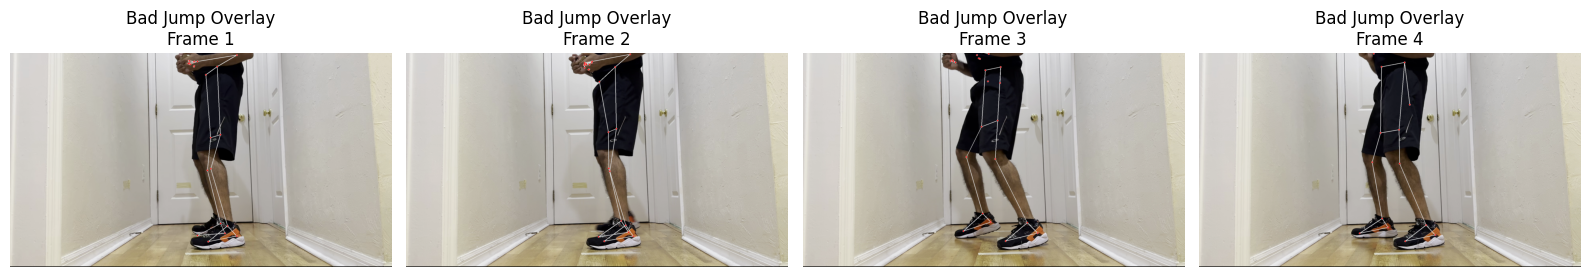

In [63]:
show_overlay_frames(bad_result, "Bad Jump Overlay")

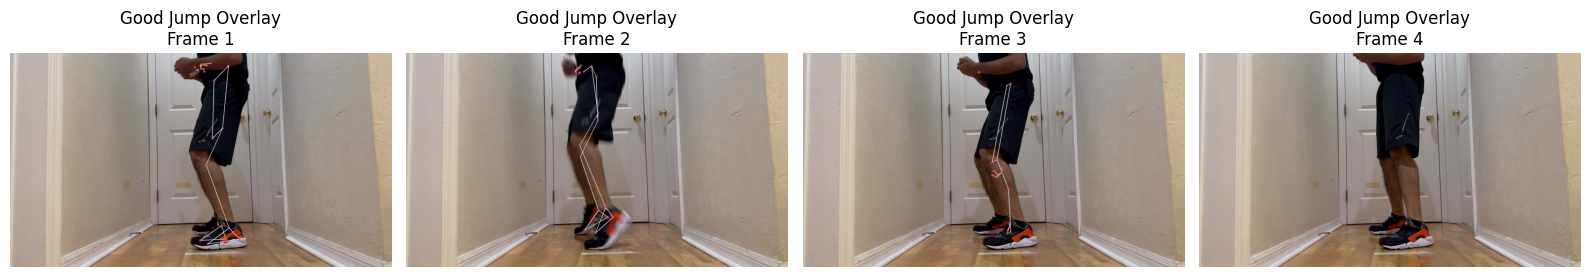

In [64]:
show_overlay_frames(good_result, "Good Jump Overlay")